<img src="../assets/header.gif" style="width:100%">
<hr style="color:#808080;">
<p align="center"><b>S H A G G Y</b></p>
<hr style="color:#808080;">

A demonstration notebook comparing our optimizers — **AdamW**, **SOAP**, **Muon**, and **HybridMA** — on a small regression task built from the ocean dataset: mapping a 4-level temperature column to the corresponding 4-level oxygen column.

In [1]:
import copy
import itertools
import matplotlib.pyplot as plt
import torch

from IPython.display import clear_output, display
from torch.utils.data import DataLoader, Dataset, random_split

from shaggy.layers import LayerNorm
from shaggy.optimizers import SOAP, HybridMA, Muon, safe_gradient_step

<hr style="color:#808080;">
<p align="center"><b>C O N F I G U R A T I O N</b></p>
<hr style="color:#808080;">

All data, model, training, and plotting parameters are grouped here.

In [2]:
config = {
    "data": {
        "n_val": 2_000,
    },
    "model": {
        "hid_features": 64,
        "num_heads": 4,
        "num_blocks": 2,
    },
    "train": {
        "lr": {"adamw": 1e-4, "soap": 1e-4, "muon": 1e-4, "hybrid": 1e-4},
        "weight_decay": 0.05,
        "steps": 1500,
        "batch_size": 256,
    },
    "plot": {
        "refresh_every": 50,
        "val_sample_size": 128,
    },
}

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<hr style="color:#808080;">
<p align="center"><b>D A T A S E T</b></p>
<hr style="color:#808080;">

Each grid pixel holds a 4-level temperature column (channels `0-3`) and a 4-level oxygen column (channels `4-7`). `ColumnDataset` extracts one `(temperature, oxygen)` pair of columns per pixel, keeping only pixels where every depth level is valid (sea) so that no column is padded with land zeros.

In [3]:
class ColumnDataset(Dataset):
    r"""Pairs of (temperature, oxygen) depth columns extracted from valid ocean pixels.

    Arguments:
        x: Data tensor, with shape (N, 8, Y, X). Channels 0-3 are temperature,
            channels 4-7 are oxygen, both ordered from surface to depth.
        mask: Validity mask, with shape (8, Y, X). 1 for sea, 0 for land.
    """

    def __init__(self, x: torch.Tensor, mask: torch.Tensor) -> None:
        x = torch.nan_to_num(x, nan=0.0)

        # Keep a pixel only if every depth level is valid (sea) at that location.
        valid = mask.all(dim=0)
        valid = valid.unsqueeze(0).expand(x.shape[0], -1, -1).reshape(-1)

        temperature = x[:, 0:4].permute(0, 2, 3, 1).reshape(-1, 4)
        oxygen = x[:, 4:8].permute(0, 2, 3, 1).reshape(-1, 4)

        self.temperature = temperature[valid]
        self.oxygen = oxygen[valid]

    def __len__(self) -> int:
        return self.temperature.shape[0]

    def __getitem__(self, idx: int) -> tuple:
        return self.temperature[idx], self.oxygen[idx]

In [4]:
# Load the raw ocean tensors.
x = torch.load("data/x.pt")
mask = torch.load("data/mask.pt")

print(f"x    : {tuple(x.shape)}")
print(f"mask : {tuple(mask.shape)}")

# Build the (temperature, oxygen) column dataset and set aside a validation split.
dataset = ColumnDataset(x, mask)

n_val = config["data"]["n_val"]
train_set, val_set = random_split(
    dataset,
    [len(dataset) - n_val, n_val],
    generator=torch.Generator().manual_seed(0),
)

print(f"Columns total : {len(dataset):,}")
print(f"Columns train : {len(train_set):,}")
print(f"Columns val   : {len(val_set):,}")

x    : (16, 8, 128, 256)
mask : (8, 128, 256)
Columns total : 227,408
Columns train : 225,408
Columns val   : 2,000


<hr style="color:#808080;">
<p align="center"><b>M O D E L</b></p>
<hr style="color:#808080;">

Instead of a plain regression, the model predicts a **mean** and a **variance** per oxygen level (heteroscedastic regression), trained with a Gaussian negative log-likelihood loss.

The 4-level temperature column is treated as a length-4 sequence and processed by a small pre-norm Transformer encoder: each level is embedded, a learned positional embedding is added, then `num_blocks` blocks of (bias-free) self-attention and (bias-free) FFN refine the representation before a final bias-free linear head predicts the mean and variance.

Every layer is either a 2D weight matrix (embeddings, attention projections, FFN, head) or has no learnable parameters at all (`LayerNorm` here has no affine parameters). This lets Muon optimize the whole network directly (it only supports 2D parameters), and makes `HybridMA` equivalent to plain Muon here, since every parameter is routed to it — this is just to show that `HybridMA` works, even in this degenerate case.

`weight_decay` is set explicitly and identically for Muon and HybridMA, since the two classes have different defaults and that would otherwise skew the comparison.

In [5]:
class TransformerBlock(torch.nn.Module):
    r"""Pre-norm Transformer encoder block with bias-free self-attention and FFN.

    Arguments:
        hid_features: Embedding dimension.
        num_heads: Number of self-attention heads.
    """

    def __init__(self, hid_features: int, num_heads: int) -> None:
        super().__init__()

        self.norm1 = LayerNorm(dim=-1)
        self.attn = torch.nn.MultiheadAttention(
            hid_features, num_heads, bias=False, batch_first=True
        )

        self.norm2 = LayerNorm(dim=-1)
        self.ffn = torch.nn.Sequential(
            torch.nn.Linear(hid_features, hid_features, bias=False),
            torch.nn.SiLU(),
            torch.nn.Linear(hid_features, hid_features, bias=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.norm1(x)
        y, _ = self.attn(y, y, y, need_weights=False)
        x = x + y

        y = self.norm2(x)
        y = self.ffn(y)
        x = x + y

        return x


class Transformer(torch.nn.Module):
    r"""Predicts the mean and variance of a 4-level oxygen column from a temperature column,
    using a small Transformer encoder over the 4 depth levels.

    Arguments:
        hid_features: Embedding dimension.
        num_heads: Number of self-attention heads.
        num_blocks: Number of Transformer encoder blocks.
    """

    def __init__(self, hid_features: int, num_heads: int, num_blocks: int) -> None:
        super().__init__()

        self.embed = torch.nn.Linear(1, hid_features, bias=False)
        self.positional = torch.nn.Parameter(torch.randn(4, hid_features) * 0.02)

        self.blocks = torch.nn.ModuleList(
            [TransformerBlock(hid_features, num_heads) for _ in range(num_blocks)]
        )

        self.head = torch.nn.Linear(4 * hid_features, 8, bias=False)

    def forward(self, x: torch.Tensor) -> tuple:
        h = self.embed(x.unsqueeze(-1)) + self.positional

        for block in self.blocks:
            h = block(h)

        mean, log_var = self.head(h.flatten(1)).chunk(2, dim=-1)
        var = torch.nn.functional.softplus(log_var) + 1e-6

        return mean, var

<hr style="color:#808080;">
<p align="center"><b>T R A I N I N G</b></p>
<hr style="color:#808080;">

Four copies of the same initial Transformer are trained in parallel, one per optimizer, on the exact same sequence of batches, for a fixed number of steps. The training loss (Gaussian NLL) is plotted live on the left. On the right, the validation MSE of the predicted mean — evaluated every `plot.refresh_every` steps on a fixed subsample of `plot.val_sample_size` held-out columns — tracks generalization without waiting for the end of training.

In [6]:
# Same initial weights for every optimizer, for a fair comparison.
torch.manual_seed(0)
reference = Transformer(
    config["model"]["hid_features"],
    config["model"]["num_heads"],
    config["model"]["num_blocks"],
).to(device)

models = {name: copy.deepcopy(reference) for name in ["adamw", "soap", "muon", "hybrid"]}

lr = config["train"]["lr"]
weight_decay = config["train"]["weight_decay"]

optimizers = {
    "adamw": torch.optim.AdamW(models["adamw"].parameters(), lr=lr["adamw"]),
    "soap": SOAP(models["soap"].parameters(), lr=lr["soap"]),
    "muon": Muon(models["muon"].parameters(), lr=lr["muon"], weight_decay=weight_decay),
    "hybrid": HybridMA(models["hybrid"], lr=lr["hybrid"], weight_decay=weight_decay),
}

# Gaussian negative log-likelihood: trains the mean and variance heads jointly.
loss_fn = torch.nn.GaussianNLLLoss()

train_loader = DataLoader(train_set, batch_size=config["train"]["batch_size"], shuffle=True)
train_iterator = itertools.cycle(train_loader)

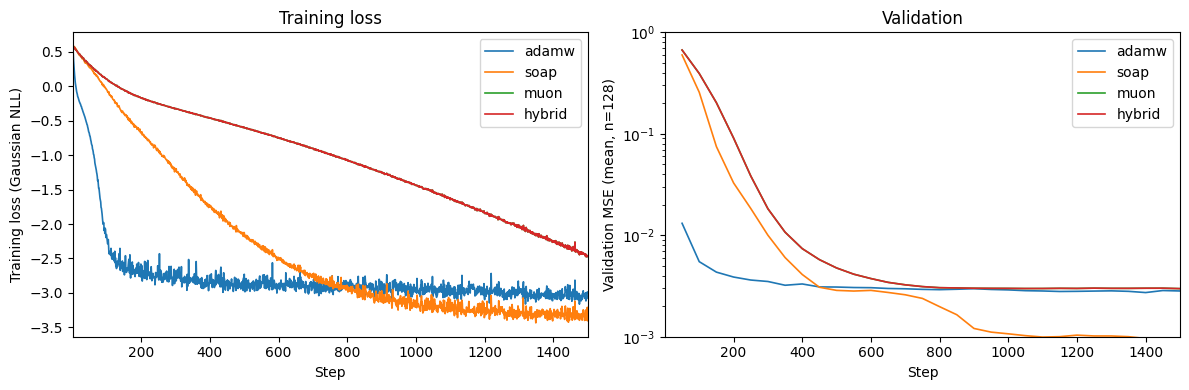

In [7]:
steps = config["train"]["steps"]
refresh_every = config["plot"]["refresh_every"]
val_sample_size = config["plot"]["val_sample_size"]

# Fixed, small validation subsample for cheap live monitoring during training.
val_temperature_sample, val_oxygen_sample = val_set[:val_sample_size]
val_temperature_sample = val_temperature_sample.to(device)
val_oxygen_sample = val_oxygen_sample.to(device)

# Fixed y-limits so the validation curves stay directly comparable across redraws.
VAL_Y_LIM = (1e-3, 1e0)

train_loss = {name: [] for name in models}
val_mse = {name: [] for name in models}
val_steps = []

fig, (ax_loss, ax_val) = plt.subplots(1, 2, figsize=(12, 4))

for step in range(1, steps + 1):
    temperature, oxygen = next(train_iterator)
    temperature, oxygen = temperature.to(device), oxygen.to(device)

    for name, model in models.items():
        model.train()
        mean, var = model(temperature)
        loss = loss_fn(mean, oxygen, var)

        loss.backward()
        safe_gradient_step(optimizers[name])

        train_loss[name].append(loss.item())

    if step % refresh_every == 0 or step == steps:
        val_steps.append(step)

        with torch.no_grad():
            for name, model in models.items():
                model.eval()
                mean, _ = model(val_temperature_sample)
                val_mse[name].append(
                    torch.mean((mean - val_oxygen_sample).square()).item()
                )

        clear_output(wait=True)

        ax_loss.clear()
        ax_val.clear()
        for name in models:
            ax_loss.plot(range(1, step + 1), train_loss[name], label=name, linewidth=1.2)
            ax_val.plot(val_steps, val_mse[name], label=name, linewidth=1.2)

        ax_loss.set_xlim(1, steps)
        ax_loss.set_xlabel("Step")
        ax_loss.set_ylabel("Training loss (Gaussian NLL)")
        ax_loss.set_title("Training loss")
        ax_loss.legend(loc="upper right")

        ax_val.set_xlim(1, steps)
        ax_val.set_ylim(*VAL_Y_LIM)
        ax_val.set_yscale("log")
        ax_val.set_xlabel("Step")
        ax_val.set_ylabel(f"Validation MSE (mean, n={val_sample_size})")
        ax_val.set_title("Validation")
        ax_val.legend(loc="upper right")

        fig.tight_layout()

        display(fig)

plt.close(fig)

<hr style="color:#808080;">
<p align="center"><b>D I A G N O S T I C S</b></p>
<hr style="color:#808080;">

Validation RMSE (between the predicted mean and the target) on the columns held out of training, with the average predicted standard deviation shown as an error bar.

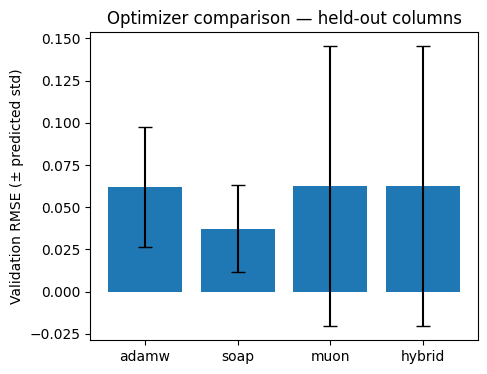

In [8]:
val_temperature, val_oxygen = val_set[:]
val_temperature, val_oxygen = val_temperature.to(device), val_oxygen.to(device)

val_rmse = {}
val_std = {}

with torch.no_grad():
    for name, model in models.items():
        model.eval()
        mean, var = model(val_temperature)
        val_rmse[name] = torch.sqrt(torch.mean((mean - val_oxygen).square())).item()
        val_std[name] = torch.sqrt(var).mean().item()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    val_rmse.keys(),
    val_rmse.values(),
    yerr=list(val_std.values()),
    capsize=5,
    color="tab:blue",
)
ax.set_ylabel("Validation RMSE (± predicted std)")
ax.set_title("Optimizer comparison — held-out columns")
plt.show()